In [9]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [10]:
import numpy as np

In [11]:
from scipy.stats import pearsonr

In [15]:
import scipy.stats as stats

Write a python code to perform the following actions.
1. Import a data set from a CSV file, The headers for the data set must be in the first row of the CSV file.
2. Generate the statistical description of all the features used in the data set. Include "object" data types as well.

In [12]:
import pandas as pd

# 1. Import a data set from a CSV file
data = pd.read_csv(URL)

# 2. Generate the statistical description of all the features
description = data.describe(include='all')

print(description)

        Unnamed: 0.1  Unnamed: 0 Manufacturer    Category         GPU  \
count     238.000000  238.000000          238  238.000000  238.000000   
unique           NaN         NaN           11         NaN         NaN   
top              NaN         NaN         Dell         NaN         NaN   
freq             NaN         NaN           71         NaN         NaN   
mean      118.500000  118.500000          NaN    3.205882    2.151261   
std        68.848868   68.848868          NaN    0.776533    0.638282   
min         0.000000    0.000000          NaN    1.000000    1.000000   
25%        59.250000   59.250000          NaN    3.000000    2.000000   
50%       118.500000  118.500000          NaN    3.000000    2.000000   
75%       177.750000  177.750000          NaN    4.000000    3.000000   
max       237.000000  237.000000          NaN    5.000000    3.000000   

                OS    CPU_core  Screen_Size_inch  CPU_frequency      RAM_GB  \
count   238.000000  238.000000        238.00

Write a Python code to perform the following actions.
1. Create regression plots for the attributes "CPU_frequency", "Screen_Size_inch" and "Weight_pounds" against "Price".
2. Create box plots for the attributes "Category", "GPU", "OS", "CPU_core", "RAM_GB" and "Storage_GB_SSD" against the attribute "Price".

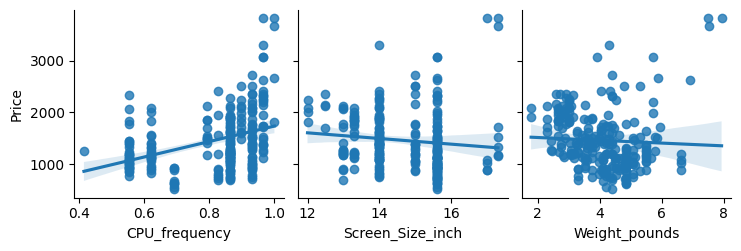

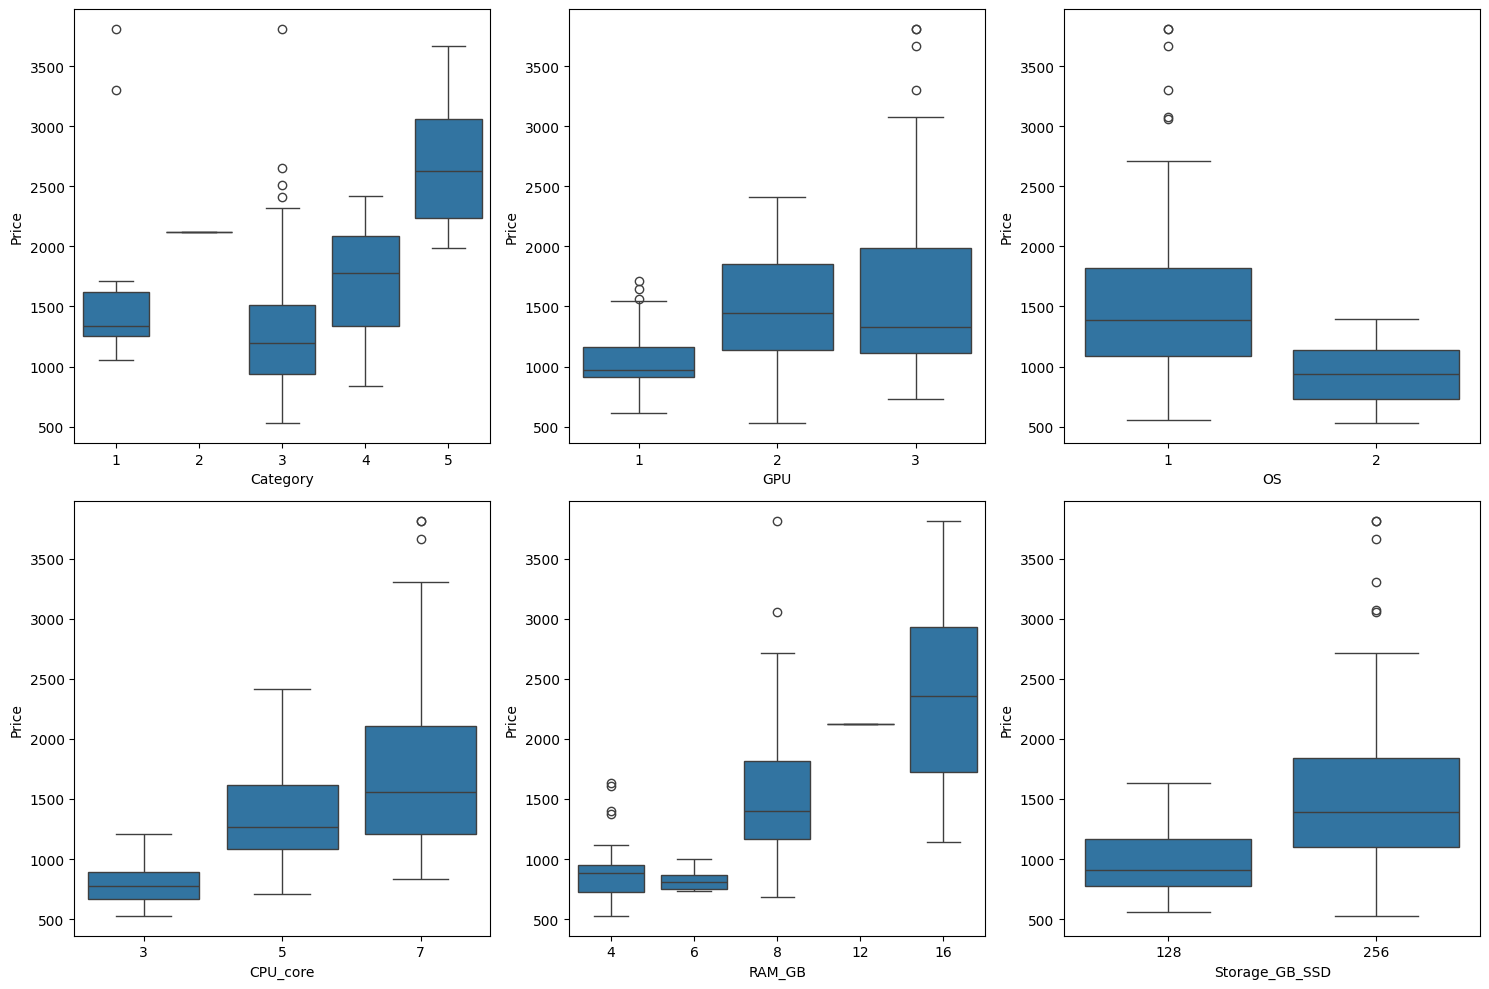

In [13]:

import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame containing the dataset

# Regression plots for CPU_frequency, Screen_Size_inch, and Weight_pounds against Price
sns.pairplot(data, x_vars=['CPU_frequency', 'Screen_Size_inch', 'Weight_pounds'], y_vars=['Price'], kind='reg')
plt.show()

# Box plots for Category, GPU, OS, CPU_core, RAM_GB, and Storage_GB_SSD against Price
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sns.boxplot(x='Category', y='Price', data=data, ax=axes[0, 0])
sns.boxplot(x='GPU', y='Price', data=data, ax=axes[0, 1])
sns.boxplot(x='OS', y='Price', data=data, ax=axes[0, 2])
sns.boxplot(x='CPU_core', y='Price', data=data, ax=axes[1, 0])
sns.boxplot(x='RAM_GB', y='Price', data=data, ax=axes[1, 1])
sns.boxplot(x='Storage_GB_SSD', y='Price', data=data, ax=axes[1, 2])
plt.tight_layout()
plt.show()

Write a Python code for the following.
1. Evaluate the correlation value, pearson coefficient and p-values for all numerical attributes against the target attribute "Price".
2. Don't include the values evaluated for target variable against itself.
3. Print these values as a part of a single dataframe against each individual attrubute.

In [18]:
# Selecting only numerical columns
numerical_columns = data.select_dtypes(include=[np.number]).columns

# Creating an empty DataFrame to store correlation, Pearson coefficient, and p-values
correlation_df = pd.DataFrame(columns=['Attribute', 'Correlation', 'Pearson Coefficient', 'P-value'])

# Calculating correlation, Pearson coefficient, and p-values for all numerical attributes against Price
for column in numerical_columns:
    if column != 'Price':  # Exclude target variable against itself
        correlation = data['Price'].corr(data[column])
        pearson_coef, p_value = stats.pearsonr(data['Price'], data[column])
        correlation_df = pd.concat([correlation_df, pd.DataFrame([[column, correlation, pearson_coef, p_value]], columns=['Attribute', 'Correlation', 'Pearson Coefficient', 'P-value'])], ignore_index=True)

print(correlation_df)

           Attribute  Correlation  Pearson Coefficient       P-value
0       Unnamed: 0.1     0.321933             0.321933  3.851058e-07
1         Unnamed: 0     0.321933             0.321933  3.851058e-07
2           Category     0.286243             0.286243  7.225696e-06
3                GPU     0.288298             0.288298  6.166950e-06
4                 OS    -0.221730            -0.221730  5.696643e-04
5           CPU_core     0.459398             0.459398  7.912950e-14
6   Screen_Size_inch    -0.110644            -0.110644  8.853398e-02
7      CPU_frequency     0.366666             0.366666  5.502463e-09
8             RAM_GB     0.549297             0.549297  3.681561e-20
9     Storage_GB_SSD     0.243421             0.243421  1.489892e-04
10     Weight_pounds    -0.050312            -0.050312  4.397694e-01
11    Screen-Full_HD    -0.021075            -0.021075  7.463568e-01
12  Screen-IPS_panel     0.021075             0.021075  7.463568e-01


C:\Users\PC\AppData\Local\Temp\ipykernel_7872\1320077971.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  correlation_df = pd.concat([correlation_df, pd.DataFrame([[column, correlation, pearson_coef, p_value]], columns=['Attribute', 'Correlation', 'Pearson Coefficient', 'P-value'])], ignore_index=True)


Write a python code that performs the following actions.
1. Group the attributes "GPU", "CPU_core" and "Price", as available in a dataframe df
2. Create a pivot table for this group, assuming the target variable to be 'Price' and aggregation function as mean
3. Plot a pcolor plot for this pivot table.

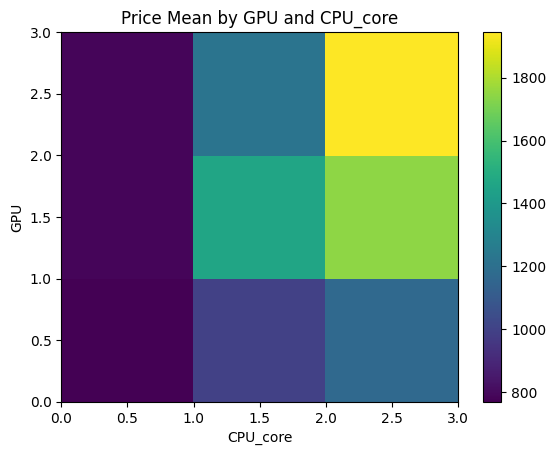

In [19]:
# Assuming 'df' is your DataFrame containing the data

# Grouping the attributes GPU, CPU_core, and Price
grouped_df = data.groupby(['GPU', 'CPU_core'])['Price'].mean().reset_index()

# Creating a pivot table for the grouped data
pivot_table = grouped_df.pivot(index='GPU', columns='CPU_core', values='Price')

# Plotting a pcolor plot for the pivot table
plt.pcolor(pivot_table, cmap='viridis')
plt.colorbar()
plt.xlabel('CPU_core')
plt.ylabel('GPU')
plt.title('Price Mean by GPU and CPU_core')
plt.show()